In [1]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
import copy
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

import torch
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from latent_model.temporal_prediction import create_models_list, create_loaders
from simulation_encoder.models.model_retrieval import load_models

In [2]:
"""Utility Functions"""
def plot_regression_results(y_true, y_pred, label_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label="Ideal Fit")
    plt.title(f"Parity Plot for {label_type}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_classification_results(y_true, y_pred, title, class_names, save_path,
                                font_size: int = 0, show: bool = True):
    
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)), normalize="true")

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        cbar=False,
        ax=ax,
        annot_kws={"size": font_size}
    )

    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)

    if show:
        plt.show()
    else:
        plt.close(fig)

In [3]:
study_name = "full-gastruloid"
results_path = f"results/{study_name}"
data_type = "gastruloid"

In [6]:
if data_type == "arcade":
    seq_len = 15
elif data_type == "gastruloid":
    seq_len = 9
elif data_type == "batch":
    seq_len = 9
elif data_type == "nasa":
    seq_len = 3
else:
    raise ValueError(f"Unknown data type: {data_type}")
loaders = create_loaders(results_path, seq_len=seq_len, random_split=True)
loaders = dict(sorted(loaders.items()))

temporal_models = defaultdict(lambda: defaultdict(list))
for model_name in os.listdir(results_path):
    model_path = f"{results_path}/{model_name}/_best_model"
    for dataset_name in os.listdir(model_path):
        loader = loaders[model_name][dataset_name]
        num_dims = loader.num_dims
        temporal_models[model_name][dataset_name] = create_models_list(
            input_size=num_dims, output_size=1, classification=True
        )
temporal_models = dict(sorted(temporal_models.items()))

if data_type == "arcade":
    inverse_mapping = {0: "colony", 1: "tissue"}
    cell_context_map = {"C": 0, "CH": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([cell_context_map[arr.split("_")[0]] for arr in sample_id])
elif data_type == "gastruloid":
    def transform_sample_id(sample_id):
        return torch.Tensor([(int(arr.split("_")[0][-1]) - 1) % 2 for arr in sample_id])
        # return torch.Tensor([(int(arr.split("_")[1][-1]) - 1) % 2 for arr in sample_id])
    inverse_mapping = {0: "euploid", 1: "anueploid"}
elif data_type == "batch":
    inverse_mapping = {250224: 0, 250609: 1, 250616: 2, 250623: 3, 250630: 4, 250715: 5, 250722: 6, 250729: 7}
    def transform_sample_id(sample_id):
        return torch.Tensor([inverse_mapping[(int(arr.split("_")[0]))] for arr in sample_id])
    
elif data_type == "nasa":
    radiation_map = {"Fe": 0, "X-ray": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([radiation_map[arr.split("_")[-1]] for arr in sample_id])
    inverse_mapping = {0: "Fe", 1: "X-ray"}

# Latent dim preditions

In [7]:
patience, max_epochs = 5, 50
best_models = defaultdict(dict)

for model_name, dataset in temporal_models.items():
    for dataset_name, models in dataset.items():
        
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train = torch.cat([e for e, _ in train_loader], dim=0)
        mean, std = all_train.mean(0, keepdim=True), all_train.std(0, keepdim=True)

        all_train = torch.cat([e for e, _ in train_loader], dim=0)
        mean, std = all_train.mean(0, keepdim=True), all_train.std(0, keepdim=True)
        normalized = (all_train - mean) / std

        dataset_best_loss   = float("inf")
        dataset_best_model  = None

        for model in models:
            best_weights = None
            best_loss = float("inf")
            no_improvement_count = 0

            for epoch in range(max_epochs):
                model.train()
                for embeddings, sample_id in train_loader:
                    x_batch = (embeddings - mean) / std
                    y_batch = transform_sample_id(sample_id)
                    
                    model.optimizer.zero_grad()
                    y_pred = model(x_batch)
                    loss = model.criterion(y_pred, y_batch.long())
                    loss.backward()
                    model.optimizer.step()

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        x_batch = (embeddings - mean) / std
                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(x_batch)
                        val_loss += model.criterion(y_pred, y_batch.long()).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_weights = copy.deepcopy(model.state_dict())
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1
                    if no_improvement_count >= patience:
                        break

            if best_weights is not None:
                model.load_state_dict(best_weights)

            if best_loss < dataset_best_loss:
                dataset_best_loss  = best_loss
                dataset_best_model = copy.deepcopy(model)

        best_models[model_name][dataset_name] = copy.deepcopy(dataset_best_model)
        print(dataset_best_model)

print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

ValueError: Target size (torch.Size([16])) must be the same as input size (torch.Size([16, 1]))

In [ ]:
for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train_embeddings = []
        for embeddings, _ in train_loader:
            all_train_embeddings.append(embeddings)

        all_train_embeddings = torch.cat(all_train_embeddings, dim=0)
        mean = all_train_embeddings.mean(dim=0, keepdim=True)
        std = all_train_embeddings.std(dim=0, keepdim=True)

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []
        
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in train_loader:
                x_batch = (embeddings - mean) / std
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                # y_pred_labels.extend(y_pred.flatten().numpy())
                y_pred_labels.extend(torch.argmax(y_pred, dim=1).cpu().numpy())
                sample_id_list.extend(sample_id)
                
        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        # class_names = inverse_mapping.values()
        class_names = inverse_mapping.keys()
        # y_test_original = [inverse_mapping[label] for label in y_true_labels]
        # y_pred_original = [inverse_mapping[label] for label in y_pred_labels]
        y_test_original = [label for label in y_true_labels]
        y_pred_original = [label for label in y_pred_labels]

        print(f"--------- Training {model_name} ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_train.png"
        # plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []
        
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = (embeddings - mean) / std
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)
                y_true_labels.extend(y_batch.numpy())
                # y_pred_labels.extend(y_pred.flatten().numpy())
                y_pred_labels.extend(torch.argmax(y_pred, dim=1).cpu().numpy())
                sample_id_list.extend(sample_id)
                
        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        # class_names = inverse_mapping.values()
        class_names = inverse_mapping.keys()
        # y_test_original = [inverse_mapping[label] for label in y_true_labels]
        # y_pred_original = [inverse_mapping[label] for label in y_pred_labels]
        y_test_original = [label for label in y_true_labels]
        y_pred_original = [label for label in y_pred_labels]

        print(f"--------- Test {model_name} ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_test.png"
        plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

In [ ]:
def permutation_importance_aggregated(model, test_loader, transform_sample_id, baseline_score, num_iterations=10):
    model.eval()
    num_features = next(iter(test_loader))[0].shape[-1]
    importance_scores = np.zeros(num_features)

    for _ in range(num_iterations):
        iteration_importance = []
        for feature_idx in range(num_features):
            y_pred_permuted = []
            y_true = []

            with torch.no_grad():
                for embeddings, sample_id in test_loader:
                    permuted_embeddings = embeddings.clone()
                    permuted_embeddings[:, :, feature_idx] = permuted_embeddings[:, torch.randperm(permuted_embeddings.size(1)), feature_idx]

                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(permuted_embeddings)

                    y_true.extend(y_batch.numpy())
                    y_pred_permuted.extend((y_pred.flatten().numpy() > 0.5).astype(int))

            permuted_score = accuracy_score(y_true, y_pred_permuted)
            importance = baseline_score - permuted_score
            iteration_importance.append(importance)

        importance_scores += np.array(iteration_importance)

    importance_scores /= num_iterations
    feature_importance = sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)
    return feature_importance

def visualize_feature_tuning(model, latent_sample, feature_idx, variation_range=(-3, 3), steps=7):
    half_steps = steps // 2
    feature_values = torch.linspace(variation_range[0], variation_range[1], steps)

    fig, axes = plt.subplots(len(latent_sample), steps, figsize=(3 * steps, 3 * len(latent_sample)))
    if len(latent_sample) == 1:
        axes = axes[None, :]

    for row, latent_vector in enumerate(latent_sample):
        with torch.no_grad():
            original_image = model.decode_image(latent_vector.unsqueeze(0)).squeeze().detach().cpu().numpy()

        for col, val in enumerate(feature_values):
            modified_latent = latent_vector.clone()

            if col == half_steps:
                image_to_plot = original_image
                title = "Original"
                cmap = 'gray'
                vmin = vmax = None
            else:
                modified_latent[feature_idx] += val
                with torch.no_grad():
                    modified_image = model.decode_image(modified_latent.unsqueeze(0)).squeeze().detach().cpu().numpy()
                diff_image = modified_image - original_image
                image_to_plot = diff_image
                title = f"{val.item():+.2f}"
                cmap = 'RdBu'
                vmax = np.max(np.abs(diff_image))
                vmin = -vmax

            axes[row, col].imshow(image_to_plot, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row, col].set_title(title)
            axes[row, col].axis('off')

    fig.savefig(f"figures/feature_tuning_{model.name}_{latent_sample.size(1)}-{feature_idx}.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [ ]:
num_iterations = 25
top_features = defaultdict(lambda: defaultdict(list))
for model_name, dataset in best_models.items():
    top_features[model_name] = {}
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")
        y_true_labels, y_pred_labels = [], []

        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = embeddings
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend((y_pred.flatten().numpy() > 0.5).astype(int))

        baseline_acc = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\nBaseline Accuracy for {model_name} | {dataset_name}: {baseline_acc:.4f}")

        feature_importances = permutation_importance_aggregated(
            model, test_loader, transform_sample_id, baseline_acc, num_iterations=num_iterations
        )
        top_features[model_name][dataset_name] = feature_importances
        print(f"Average FI for classificaiton (over {num_iterations} iterations):")
        for idx, imp in feature_importances:
            print(f"  Latent dimension {idx}: importance = {imp:.4f}")

In [ ]:
for model_name, dataset_importances in top_features.items():
    for dataset_name, importances in dataset_importances.items():
        sorted_importances = sorted(importances, key=lambda x: x[1], reverse=True)
        feature_indices, importance_values = zip(*sorted_importances)

        plt.figure(figsize=(8, len(feature_indices) * 0.4))
        plt.barh(range(len(feature_indices)), importance_values, tick_label=feature_indices)
        plt.xlabel("Importance Score")
        plt.ylabel("Latent Dimension Index")
        plt.title(f"Feature Importance: {model_name} | {dataset_name}")
        plt.gca().invert_yaxis()  # most important on top
        plt.tight_layout()
        plt.show()

In [ ]:
all_results_data = {
    "study_name": study_name,
    "model_dataset_results": []
}

for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")
        

        model.eval()
        correct = []
        incorrect = []
        for loader in [train_loader, val_loader, test_loader]:
            y_true_labels = []
            y_pred_labels = []
            sample_id_list = []

            with torch.no_grad():
                for embeddings, sample_id in loader:
                    x_batch = embeddings
                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(x_batch)

                    y_true_labels.extend(y_batch.numpy())
                    y_pred_labels.extend(y_pred.flatten().numpy())
                    sample_id_list.extend(sample_id)

            y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
            y_true_original = [inverse_mapping[label] for label in y_true_labels]
            y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

            correct.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt == yp])
            incorrect.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt != yp])

        current_model_dataset_results = {
            "model_name": model_name,
            "dataset_name": dataset_name,
            "total_correct": len(correct),
            "total_incorrect": len(incorrect),
            "correct_predictions": correct,
            "incorrect_predictions": incorrect
        }

        all_results_data["model_dataset_results"].append(current_model_dataset_results)

# json_filename = f"results_downstream/{study_name}_classification_results.json"
# with open(json_filename, 'w') as f:
#     json.dump(all_results_data, f, indent=4)

# PCA predictions

ae-small_frac10
0.6788061
0.5832737
0.4477453
0.46007723
0.49704853
0.4561296
0.46399996
0.41831502


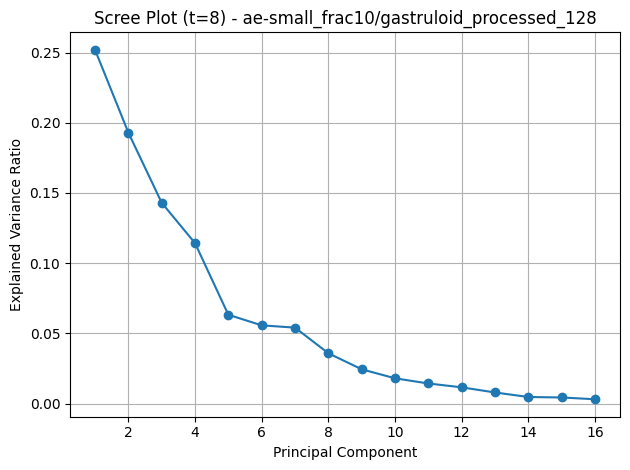

[0.25193903 0.19298297 0.14304177 0.11428076 0.06329199 0.05575354
 0.05412779 0.03588768 0.02445647 0.01804925 0.01435487 0.01161984
 0.00795296 0.00473372 0.00439419 0.00313313]
0.41016883
ae-small_frac100
0.48912504
0.47574595
0.43577635
0.43531278
0.4321742
0.42907155
0.40764558
0.40380427


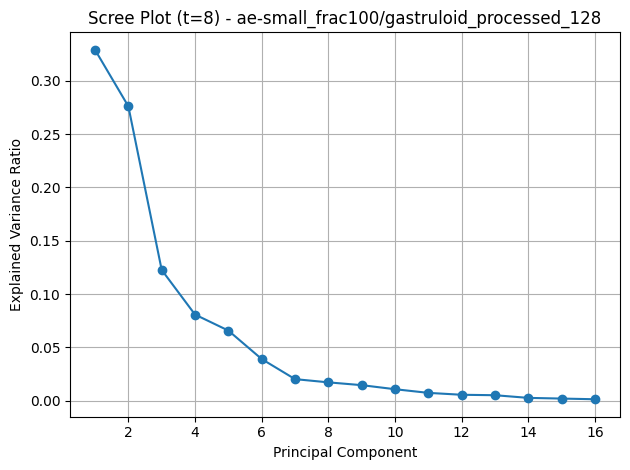

[0.32915393 0.27613506 0.1226466  0.08076926 0.06575101 0.03905439
 0.02020004 0.01717258 0.01454736 0.01073974 0.00731007 0.00552371
 0.0051051  0.00260517 0.00196203 0.00132387]
0.4377812
ae-small_frac25
0.77787054
0.5249465
0.55073833
0.5291332
0.5232765
0.42347136
0.42865705
0.4115284


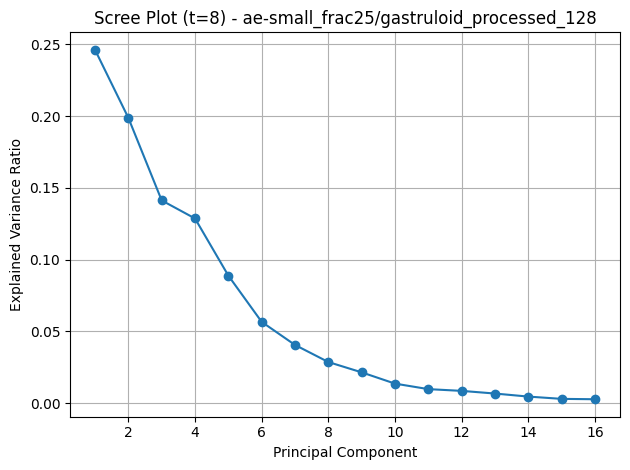

[0.24619992 0.19879498 0.14125523 0.12867196 0.08884934 0.05663078
 0.04054893 0.02864971 0.02146464 0.01361127 0.00977733 0.00855455
 0.00669961 0.00457871 0.00298959 0.00272346]
0.4101961
ae-small_frac5
0.71350473
0.56867087
0.4613062
0.45701525
0.4542279
0.46123496
0.46769387
0.46348625


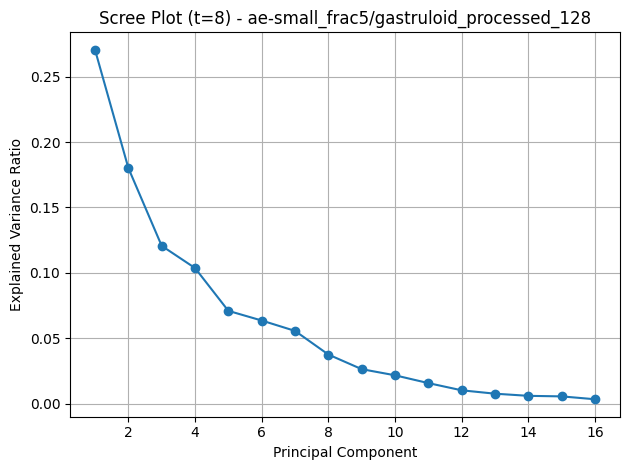

[0.27050152 0.18016097 0.12068387 0.10371897 0.07100052 0.06361021
 0.05567778 0.03761268 0.02643787 0.02174287 0.01578274 0.01027206
 0.00768887 0.00604675 0.00562461 0.00343776]
0.4399365
ae-small_frac50
0.7209345
0.56217694
0.51295996
0.5094493
0.49085572
0.41860268
0.40488258
0.412764


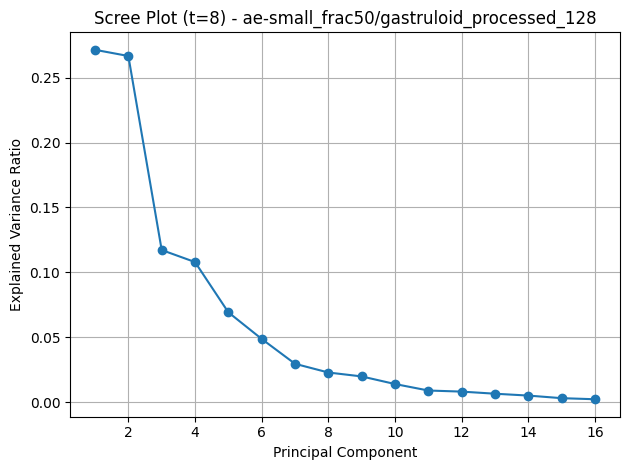

[0.2714547  0.2666774  0.11714132 0.10785782 0.06913814 0.04862038
 0.02945268 0.02274146 0.01972589 0.01385614 0.00886125 0.00802163
 0.00639822 0.0049571  0.00296453 0.00213133]
0.40275013
ae-small_frac75
0.7159837
0.40284276
0.43732062
0.44130677
0.44633177
0.41131118
0.3993601
0.4240318


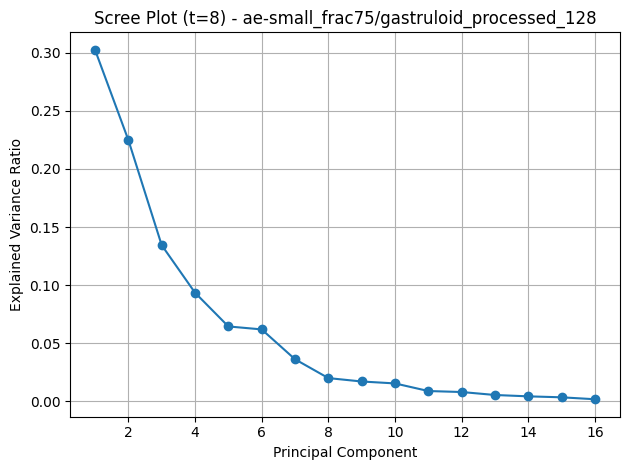

[0.30272236 0.22498013 0.13436134 0.09339318 0.06431261 0.06176164
 0.03603559 0.01980279 0.01686937 0.01520767 0.00865174 0.00779573
 0.00523603 0.00406465 0.00323706 0.00156806]
0.4318003
cae-medium_frac10
0.6451508
0.48682266
0.46357366
0.4857409
0.51465136
0.4317609
0.44395673
0.4265398


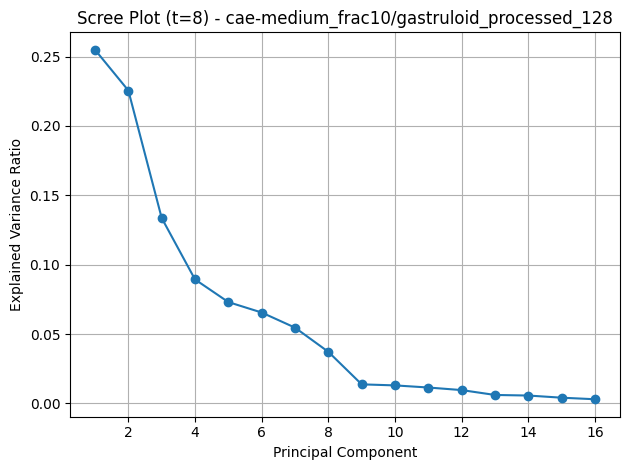

[0.2548836  0.22553785 0.13363093 0.08933153 0.07301163 0.06548454
 0.05458804 0.03714786 0.01370255 0.01294923 0.01142037 0.00956909
 0.00605605 0.0056398  0.00408343 0.00296356]
0.4113947
cae-medium_frac100
0.6122467
0.5429369
0.46769816
0.49179715
0.49805287
0.52822226
0.49510708
0.48510805


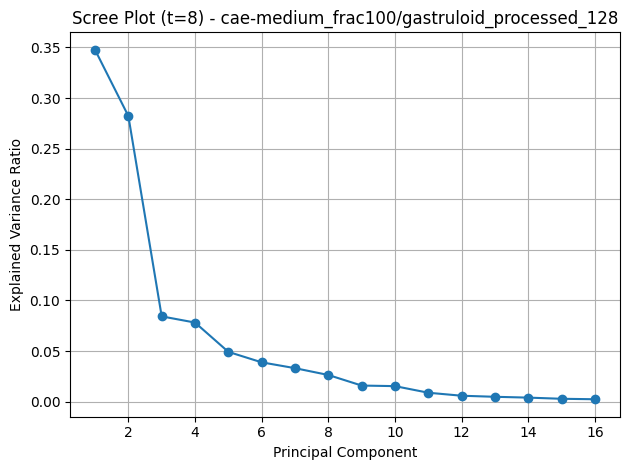

[0.34764293 0.28221217 0.08428786 0.07816461 0.04920993 0.03887678
 0.03310707 0.02636908 0.01593217 0.01536139 0.00883849 0.00588137
 0.00483069 0.00401671 0.00286407 0.00240472]
0.45579016
cae-medium_frac25
0.6905553
0.54536134
0.5314573
0.5496286
0.5055039
0.43082657
0.40990138
0.42058194


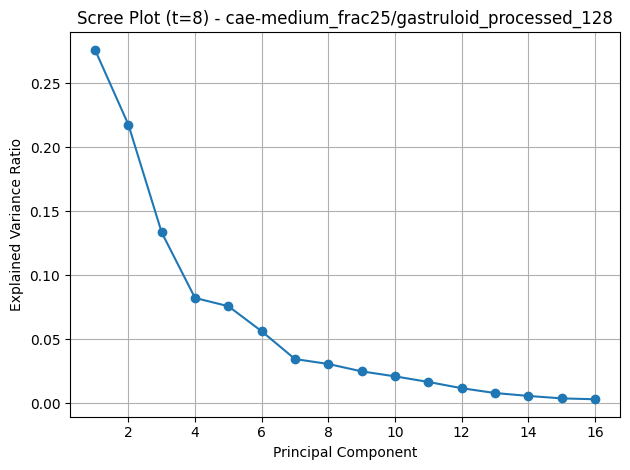

[0.27604866 0.21763617 0.13331315 0.08216054 0.07572042 0.0561248
 0.03440328 0.03056328 0.02479457 0.02089602 0.01652164 0.01164174
 0.00787856 0.00560325 0.00368405 0.00300989]
0.42821193
cae-medium_frac5
0.5806799
0.563813
0.60842097
0.6002933
0.6153764
0.48982316
0.41519907
0.42373946


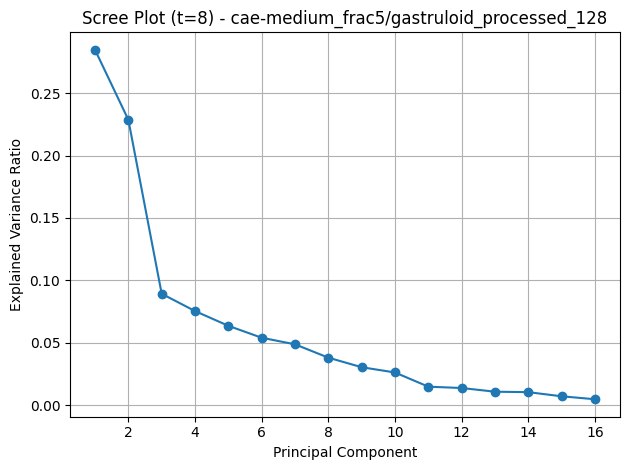

[0.28486097 0.2287389  0.0892242  0.07538136 0.06353568 0.05397832
 0.04870341 0.03799421 0.03034565 0.02611365 0.01473374 0.01366109
 0.01070928 0.01034067 0.00702205 0.00465686]
0.45144746
cae-medium_frac50
0.7147302
0.5610469
0.45341474
0.4446911
0.4786319
0.45941788
0.44055742
0.45549017


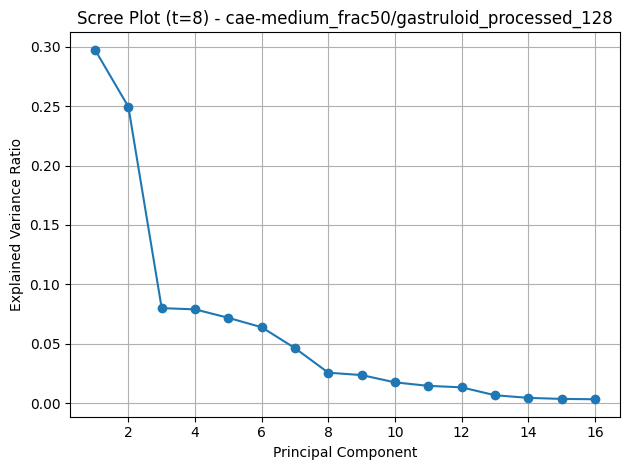

[0.29750973 0.2495473  0.07995226 0.07894094 0.07180443 0.06386377
 0.04623544 0.02557522 0.0235915  0.01745397 0.0145168  0.01325616
 0.00660664 0.00439436 0.00351881 0.0032328 ]
0.4567916
cae-medium_frac75
0.75789934
0.50187725
0.4344015
0.47352234
0.47606456
0.50222707
0.43903401
0.44811085


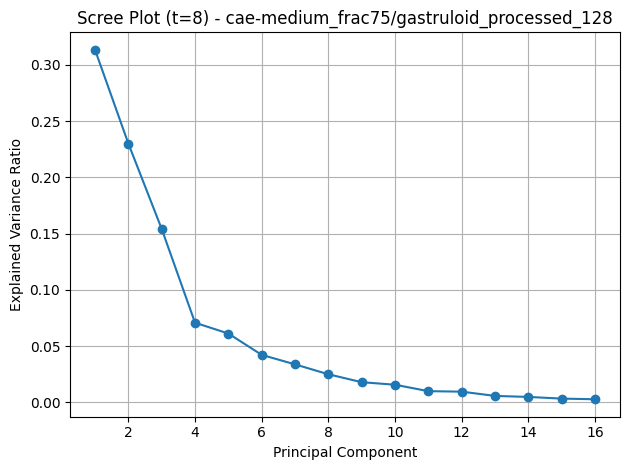

[0.3133107  0.22998637 0.15412843 0.07077555 0.06116607 0.04221288
 0.03376217 0.02497448 0.01790758 0.01566735 0.00995394 0.00950893
 0.0057272  0.00482915 0.0033287  0.00276053]
0.4404846
neuralop-medium_frac10
0.6602731
0.51359093
0.5146904
0.5188495
0.5403297
0.45949668
0.43121192
0.42916724


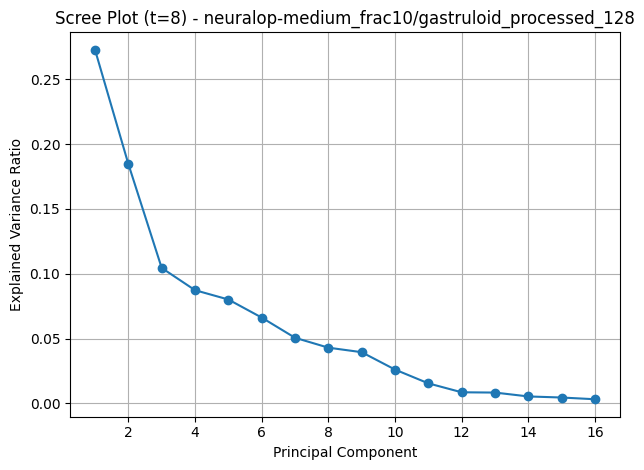

[0.2727349  0.18463312 0.1044672  0.08731446 0.08012309 0.06618381
 0.05060739 0.04297453 0.039486   0.02607514 0.01545029 0.00855744
 0.00834004 0.00534795 0.00451868 0.00318602]
0.4568568
neuralop-medium_frac100
0.5215201
0.40074265
0.427755
0.44674796
0.4414111
0.4381062
0.4774913
0.44821125


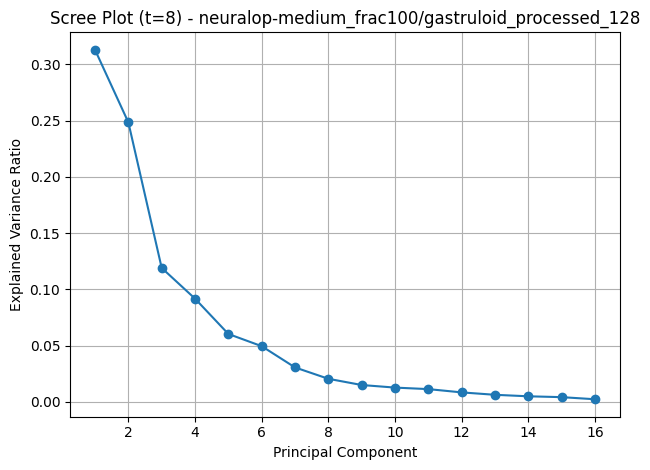

[0.31302184 0.2485343  0.11915028 0.09184638 0.06046568 0.04960714
 0.03071635 0.02061613 0.01508666 0.0127956  0.01144302 0.00853112
 0.00639134 0.00505335 0.00430554 0.0024353 ]
0.432875
neuralop-medium_frac25
0.69343746
0.5883002
0.54653347
0.5221511
0.51716727
0.46692845
0.45219728
0.44249818


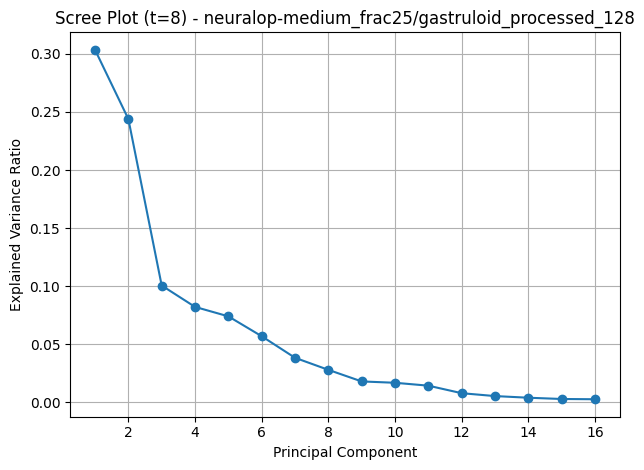

[0.30344528 0.24388976 0.10059803 0.08219802 0.07406144 0.05695422
 0.03840208 0.02802768 0.01805255 0.01689663 0.01440147 0.0079275
 0.00545067 0.004032   0.00294411 0.00271854]
0.44592085
neuralop-medium_frac5
0.6605092
0.57859164
0.44638416
0.43961358
0.44697165
0.49590605
0.516395
0.53775555


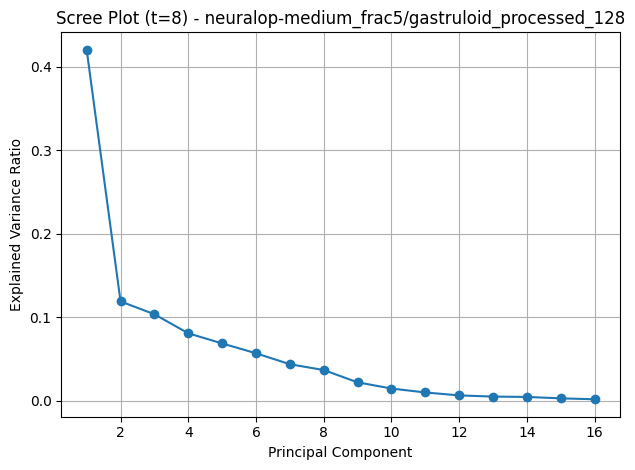

[0.42042407 0.11915403 0.1037782  0.08096347 0.06884912 0.0570603
 0.04393782 0.03698258 0.02225868 0.01484501 0.01011904 0.0066049
 0.00518213 0.00476843 0.00307534 0.00199689]
0.56684303
neuralop-medium_frac50
0.76462525
0.5293101
0.488977
0.50866663
0.5197189
0.4774318
0.45052725
0.4285892


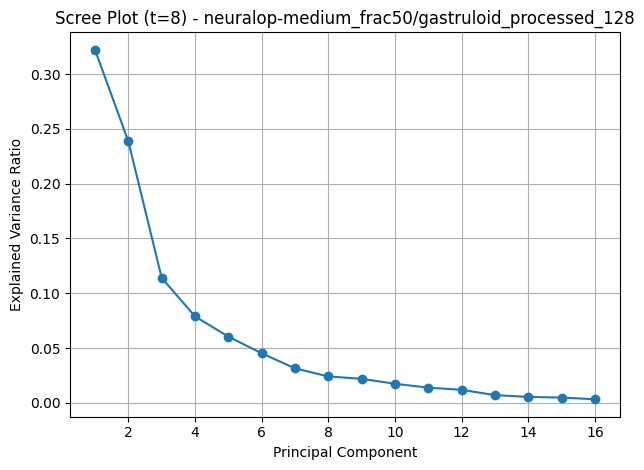

[0.32224277 0.23865293 0.11398696 0.07885264 0.06040239 0.04517108
 0.03143435 0.02405992 0.02186367 0.01736877 0.01379451 0.01185688
 0.00697898 0.00536796 0.00474193 0.00322425]
0.45316803
neuralop-medium_frac75
0.63303137
0.64131355
0.5438445
0.5056681
0.49904072
0.4785537
0.510674
0.5420832


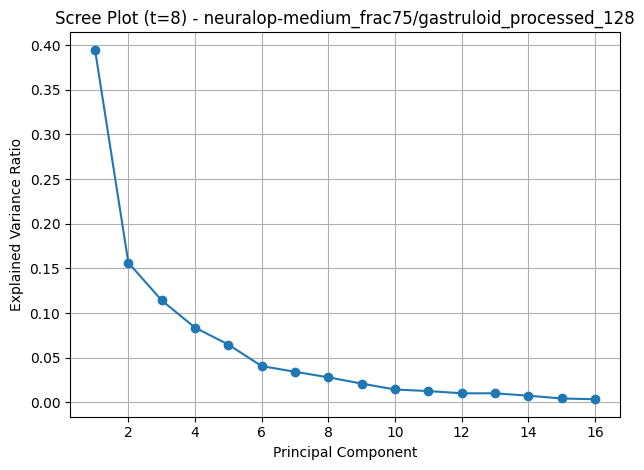

[0.39462417 0.1563262  0.11415695 0.08365323 0.06471209 0.04056626
 0.03428897 0.02800942 0.02102452 0.01441118 0.01262784 0.01017418
 0.01011865 0.00748227 0.00433508 0.00348904]
0.5323062


In [35]:
pcas = defaultdict(dict)
n_components = 16

for model_name, dataset in temporal_models.items():
    print(model_name)
    for dataset_name, models in dataset.items():

        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train = torch.cat([e for e, _ in train_loader], dim=0)
        mean, std = all_train.mean(0, keepdim=True), all_train.std(0, keepdim=True)
        normalized = (all_train - mean) / std

        T = normalized.shape[1]
        

        pca_list = []
        variance_explained = []
        for t in range(T):
            pca_t = PCA()
            pca_t.fit(normalized[:, t].numpy())

            if t == 8:
                plt.figure()
                plt.plot(range(1, len(pca_t.explained_variance_ratio_) + 1),
                         pca_t.explained_variance_ratio_, marker='o')
                plt.title(f"Scree Plot (t={t}) - {model_name}/{dataset_name}")
                plt.xlabel("Principal Component")
                plt.ylabel("Explained Variance Ratio")
                plt.grid(True)
                plt.tight_layout()
                plt.show()

                print(pca_t.explained_variance_ratio_)

            pca_t_reduced = PCA(n_components=n_components)
            pca_t_reduced.fit(normalized[:, t].numpy())
            pca_list.append(pca_t_reduced)
            variance_explained.append(pca_t.explained_variance_)
            
            pc_indices = [0, 4, 6, 8, 11, 13]
            # pc_indices = [0, 1, 2, 4, 5, 12]
            explained_variance = pca_t_reduced.explained_variance_ratio_
            total = sum(explained_variance[i] for i in pc_indices)
            print(total)

        pcas[model_name][dataset_name] = {
            "pca_list": pca_list,
            "mean": mean,
            "std": std,
            "variance_explained": variance_explained
        }


In [36]:
patience, max_epochs = 5, 50
best_pca_models = defaultdict(dict)

for model_name, dataset in temporal_models.items():
    for dataset_name, models in dataset.items():

        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        pca_info = pcas[model_name][dataset_name]
        pca_list = pca_info["pca_list"]
        mean = pca_info["mean"]
        std = pca_info["std"]

        dataset_best_loss = float("inf")
        dataset_best_model = None

        for model in models:
            best_weights = None
            best_loss = float("inf")
            no_improvement_count = 0

            for epoch in range(max_epochs):
                model.train()
                for embeddings, sample_id in train_loader:
                    y_batch = transform_sample_id(sample_id)
                    normalized = (embeddings - mean) / std
                    pca_transformed = []
                    for t, pca in enumerate(pca_list):
                        X_t = normalized[:, t].numpy().reshape(len(embeddings), -1)
                        X_pca = pca.transform(X_t)
                        pca_transformed.append(torch.tensor(X_pca, dtype=torch.float32))

                    pca_input = torch.stack(pca_transformed, dim=1).to(embeddings.device)
                    y_pred = model(pca_input)
                    loss = model.criterion(y_pred.flatten(), y_batch)
                    loss.backward()
                    model.optimizer.step()

                model.eval()
                val_loss = 0.0

                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        y_batch = transform_sample_id(sample_id)
                        normalized = (embeddings - mean) / std
                        pca_transformed = []
                        for t, pca in enumerate(pca_list):
                            X_t = normalized[:, t].cpu().numpy()
                            X_pca = pca.transform(X_t)
                            pca_transformed.append(torch.tensor(X_pca, dtype=torch.float32))

                        pca_input = torch.stack(pca_transformed, dim=1).to(embeddings.device)

                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(pca_input)
                        val_loss += model.criterion(y_pred.flatten(), y_batch).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_weights = copy.deepcopy(model.state_dict())
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1
                    if no_improvement_count >= patience:
                        break

            if best_weights is not None:
                model.load_state_dict(best_weights)

            if best_loss < dataset_best_loss:
                dataset_best_loss = best_loss
                dataset_best_model = copy.deepcopy(model)

        best_pca_models[model_name][dataset_name] = copy.deepcopy(dataset_best_model)
        print(dataset_best_model)

print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

LSTMModel(
  (lstm): LSTM(16, 32, num_layers=3, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): BCEWithLogitsLoss()
)
LSTMModel(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): BCEWithLogitsLoss()
)
LSTMModel(
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): BCEWithLogitsLoss()
)
LSTMModel(
  (lstm): LSTM(16, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): BCEWithLogitsLoss()
)
LSTMModel(
  (lstm): LSTM(16, 32, num_layers=3, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): BCEWithLogitsLoss()
)
LSTMModel(
  (lstm): LSTM(16, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=

--------- Train ae-small_frac10 ------------
              precision    recall  f1-score   support

   anueploid       0.99      0.53      0.69       262
     euploid       0.67      1.00      0.80       250

    accuracy                           0.76       512
   macro avg       0.83      0.76      0.74       512
weighted avg       0.83      0.76      0.74       512



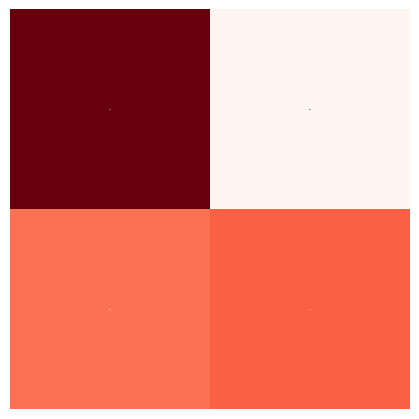

--------- Test ae-small_frac10 ------------
              precision    recall  f1-score   support

   anueploid       1.00      0.54      0.70        81
     euploid       0.68      1.00      0.81        80

    accuracy                           0.77       161
   macro avg       0.84      0.77      0.76       161
weighted avg       0.84      0.77      0.76       161



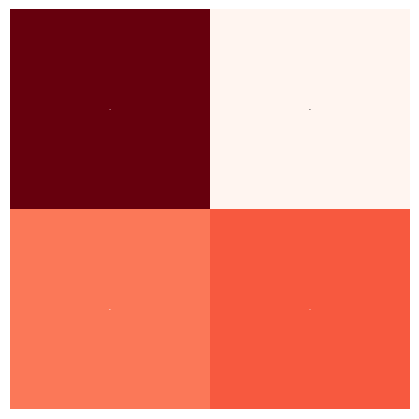

--------- Train ae-small_frac100 ------------
              precision    recall  f1-score   support

   anueploid       0.87      0.45      0.59       343
     euploid       0.62      0.93      0.74       326

    accuracy                           0.68       669
   macro avg       0.74      0.69      0.67       669
weighted avg       0.74      0.68      0.66       669



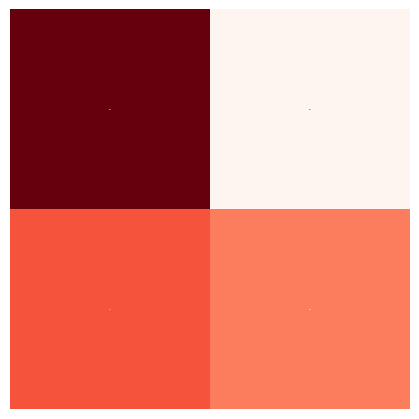

--------- Test ae-small_frac100 ------------
              precision    recall  f1-score   support

   anueploid       0.81      0.39      0.52        98
     euploid       0.63      0.92      0.75       112

    accuracy                           0.67       210
   macro avg       0.72      0.65      0.64       210
weighted avg       0.71      0.67      0.64       210



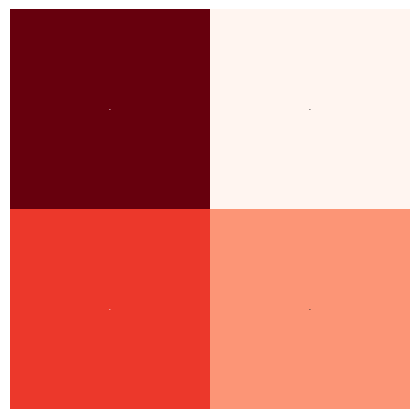

--------- Train ae-small_frac25 ------------
              precision    recall  f1-score   support

   anueploid       0.95      0.55      0.70       323
     euploid       0.68      0.97      0.80       313

    accuracy                           0.76       636
   macro avg       0.81      0.76      0.75       636
weighted avg       0.81      0.76      0.75       636



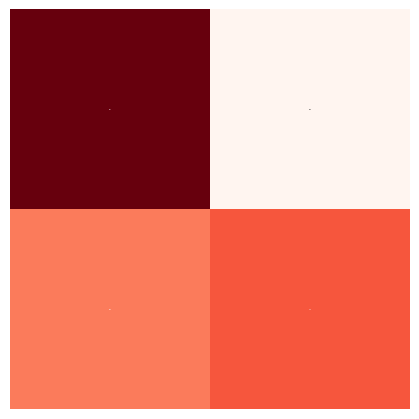

--------- Test ae-small_frac25 ------------
              precision    recall  f1-score   support

   anueploid       0.95      0.58      0.72        97
     euploid       0.71      0.97      0.82       103

    accuracy                           0.78       200
   macro avg       0.83      0.77      0.77       200
weighted avg       0.83      0.78      0.77       200



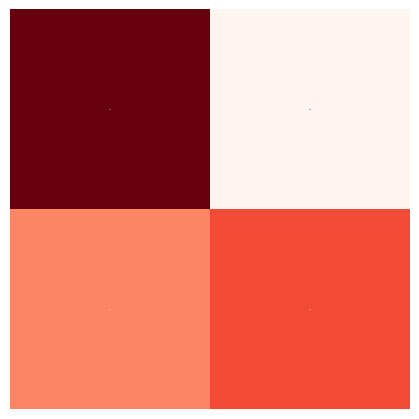

--------- Train ae-small_frac5 ------------
              precision    recall  f1-score   support

   anueploid       1.00      0.66      0.79       220
     euploid       0.72      1.00      0.84       192

    accuracy                           0.82       412
   macro avg       0.86      0.83      0.82       412
weighted avg       0.87      0.82      0.81       412



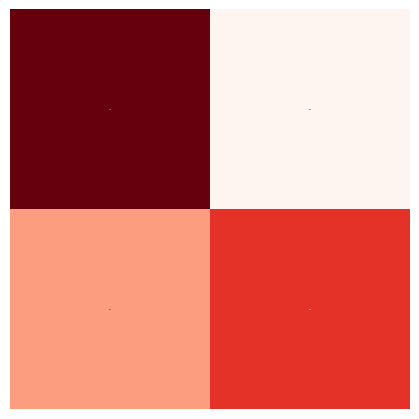

--------- Test ae-small_frac5 ------------
              precision    recall  f1-score   support

   anueploid       0.95      0.64      0.77        56
     euploid       0.78      0.97      0.87        74

    accuracy                           0.83       130
   macro avg       0.86      0.81      0.82       130
weighted avg       0.85      0.83      0.82       130



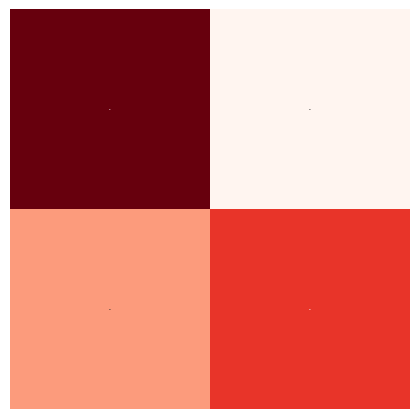

--------- Train ae-small_frac50 ------------
              precision    recall  f1-score   support

   anueploid       0.87      0.64      0.74       348
     euploid       0.70      0.90      0.79       320

    accuracy                           0.76       668
   macro avg       0.78      0.77      0.76       668
weighted avg       0.79      0.76      0.76       668



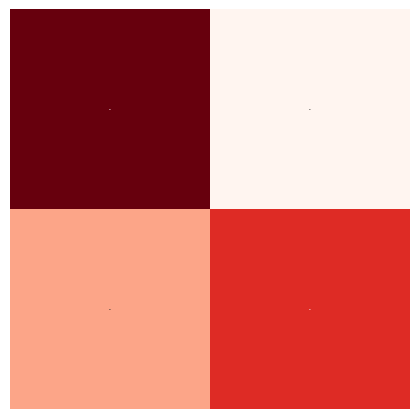

--------- Test ae-small_frac50 ------------
              precision    recall  f1-score   support

   anueploid       0.72      0.62      0.67       102
     euploid       0.68      0.78      0.73       108

    accuracy                           0.70       210
   macro avg       0.70      0.70      0.70       210
weighted avg       0.70      0.70      0.70       210



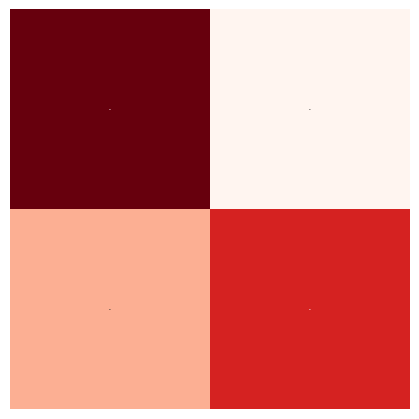

--------- Train ae-small_frac75 ------------
              precision    recall  f1-score   support

   anueploid       0.97      0.42      0.59       343
     euploid       0.62      0.99      0.76       326

    accuracy                           0.70       669
   macro avg       0.80      0.70      0.67       669
weighted avg       0.80      0.70      0.67       669



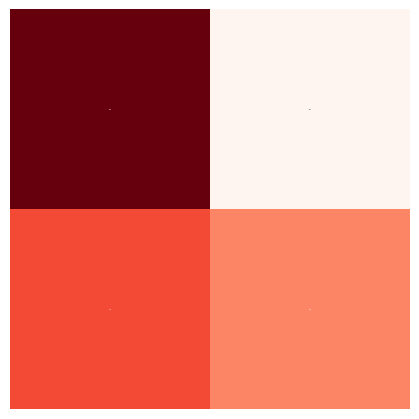

--------- Test ae-small_frac75 ------------
              precision    recall  f1-score   support

   anueploid       0.90      0.44      0.59        98
     euploid       0.66      0.96      0.78       112

    accuracy                           0.71       210
   macro avg       0.78      0.70      0.69       210
weighted avg       0.77      0.71      0.69       210



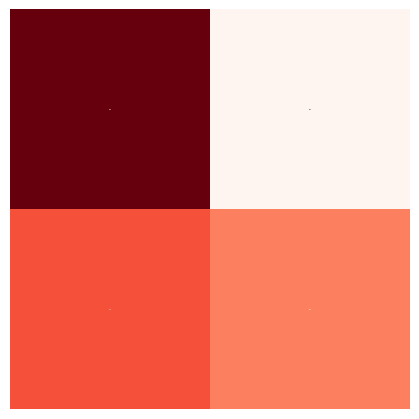

--------- Train cae-medium_frac10 ------------
              precision    recall  f1-score   support

   anueploid       0.99      0.52      0.68       262
     euploid       0.66      1.00      0.80       250

    accuracy                           0.75       512
   macro avg       0.83      0.76      0.74       512
weighted avg       0.83      0.75      0.74       512



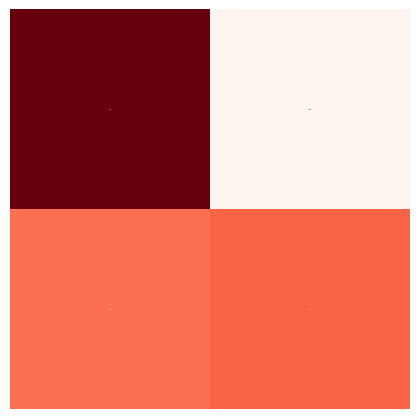

--------- Test cae-medium_frac10 ------------
              precision    recall  f1-score   support

   anueploid       1.00      0.53      0.69        81
     euploid       0.68      1.00      0.81        80

    accuracy                           0.76       161
   macro avg       0.84      0.77      0.75       161
weighted avg       0.84      0.76      0.75       161



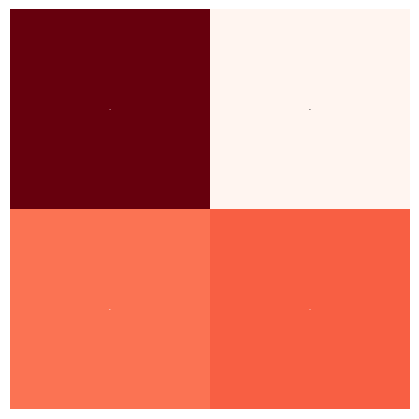

--------- Train cae-medium_frac100 ------------
              precision    recall  f1-score   support

   anueploid       0.74      0.54      0.62       343
     euploid       0.62      0.80      0.70       326

    accuracy                           0.67       669
   macro avg       0.68      0.67      0.66       669
weighted avg       0.68      0.67      0.66       669



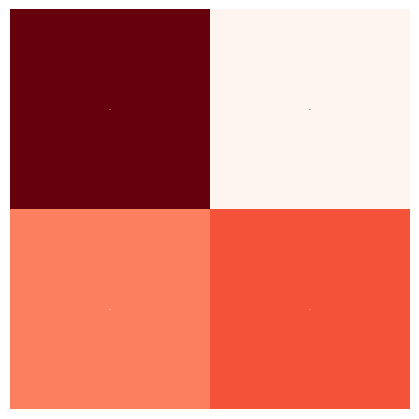

--------- Test cae-medium_frac100 ------------
              precision    recall  f1-score   support

   anueploid       0.67      0.59      0.63        98
     euploid       0.67      0.74      0.71       112

    accuracy                           0.67       210
   macro avg       0.67      0.67      0.67       210
weighted avg       0.67      0.67      0.67       210



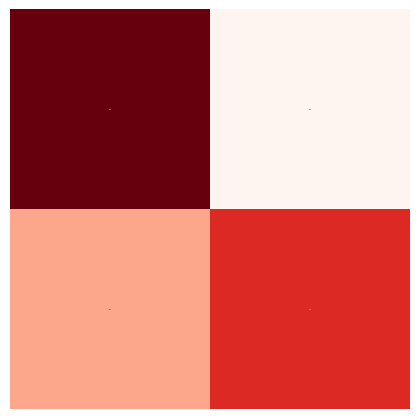

--------- Train cae-medium_frac25 ------------
              precision    recall  f1-score   support

   anueploid       0.99      0.39      0.56       323
     euploid       0.61      1.00      0.76       313

    accuracy                           0.69       636
   macro avg       0.80      0.69      0.66       636
weighted avg       0.81      0.69      0.66       636



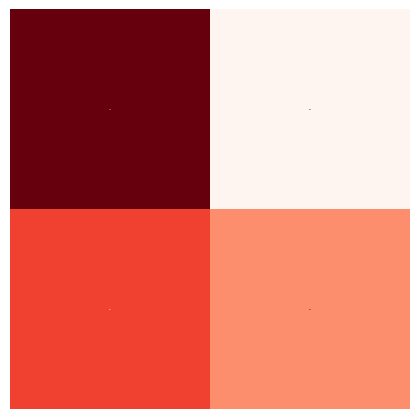

--------- Test cae-medium_frac25 ------------
              precision    recall  f1-score   support

   anueploid       1.00      0.47      0.64        97
     euploid       0.67      1.00      0.80       103

    accuracy                           0.74       200
   macro avg       0.83      0.74      0.72       200
weighted avg       0.83      0.74      0.72       200



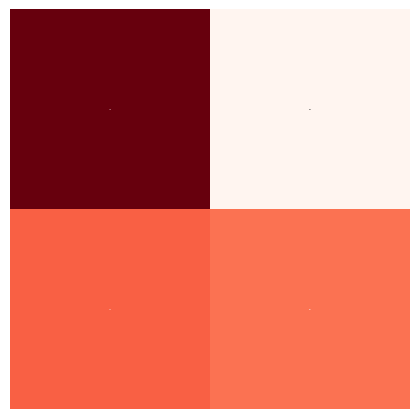

--------- Train cae-medium_frac5 ------------
              precision    recall  f1-score   support

   anueploid       0.99      0.66      0.79       220
     euploid       0.72      0.99      0.83       192

    accuracy                           0.82       412
   macro avg       0.86      0.83      0.81       412
weighted avg       0.86      0.82      0.81       412



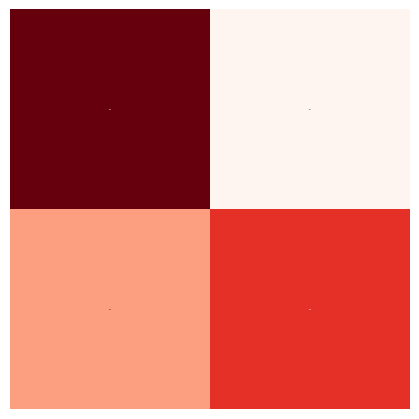

--------- Test cae-medium_frac5 ------------
              precision    recall  f1-score   support

   anueploid       0.95      0.62      0.75        56
     euploid       0.77      0.97      0.86        74

    accuracy                           0.82       130
   macro avg       0.86      0.80      0.81       130
weighted avg       0.85      0.82      0.82       130



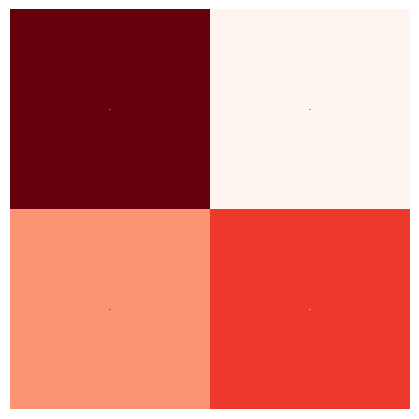

--------- Train cae-medium_frac50 ------------
              precision    recall  f1-score   support

   anueploid       0.99      0.40      0.57       348
     euploid       0.60      1.00      0.75       320

    accuracy                           0.69       668
   macro avg       0.80      0.70      0.66       668
weighted avg       0.81      0.69      0.66       668



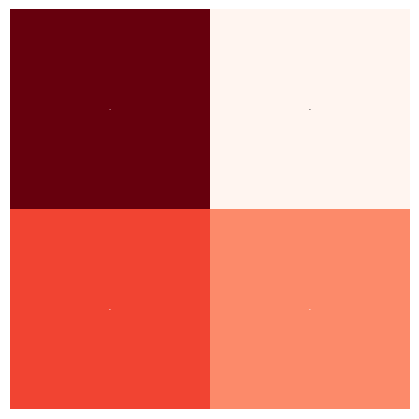

--------- Test cae-medium_frac50 ------------
              precision    recall  f1-score   support

   anueploid       0.98      0.47      0.64       102
     euploid       0.66      0.99      0.80       108

    accuracy                           0.74       210
   macro avg       0.82      0.73      0.72       210
weighted avg       0.82      0.74      0.72       210



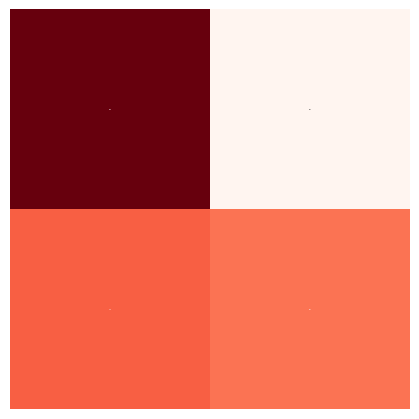

--------- Train cae-medium_frac75 ------------
              precision    recall  f1-score   support

   anueploid       0.87      0.40      0.55       343
     euploid       0.60      0.94      0.73       326

    accuracy                           0.66       669
   macro avg       0.73      0.67      0.64       669
weighted avg       0.74      0.66      0.64       669



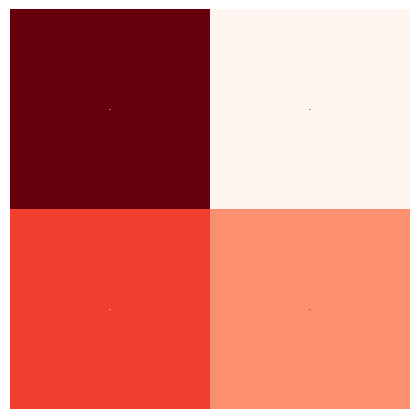

--------- Test cae-medium_frac75 ------------
              precision    recall  f1-score   support

   anueploid       0.80      0.46      0.58        98
     euploid       0.66      0.90      0.76       112

    accuracy                           0.70       210
   macro avg       0.73      0.68      0.67       210
weighted avg       0.72      0.70      0.68       210



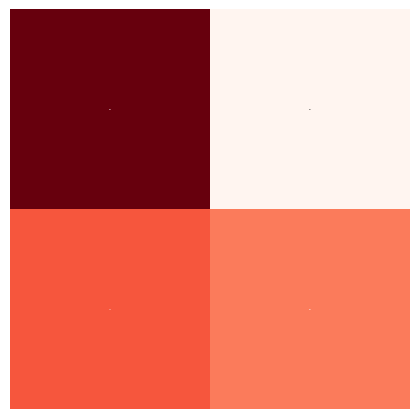

--------- Train neuralop-medium_frac10 ------------
              precision    recall  f1-score   support

   anueploid       0.97      0.58      0.73       262
     euploid       0.69      0.98      0.81       250

    accuracy                           0.78       512
   macro avg       0.83      0.78      0.77       512
weighted avg       0.84      0.78      0.77       512



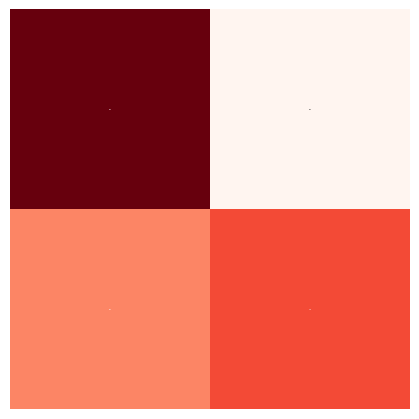

--------- Test neuralop-medium_frac10 ------------
              precision    recall  f1-score   support

   anueploid       0.96      0.57      0.71        81
     euploid       0.69      0.97      0.81        80

    accuracy                           0.77       161
   macro avg       0.82      0.77      0.76       161
weighted avg       0.83      0.77      0.76       161



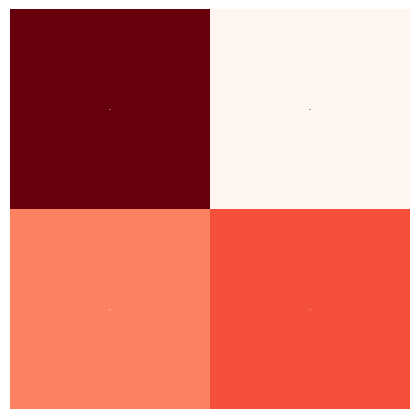

--------- Train neuralop-medium_frac100 ------------
              precision    recall  f1-score   support

   anueploid       0.88      0.57      0.69       343
     euploid       0.67      0.91      0.77       326

    accuracy                           0.74       669
   macro avg       0.77      0.74      0.73       669
weighted avg       0.78      0.74      0.73       669



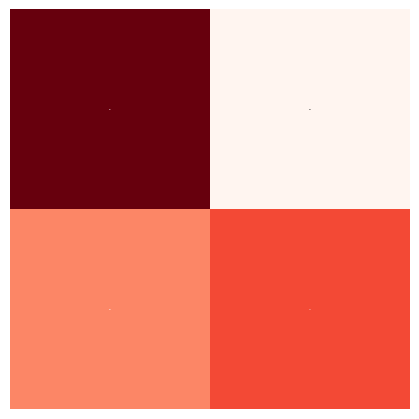

--------- Test neuralop-medium_frac100 ------------
              precision    recall  f1-score   support

   anueploid       0.73      0.53      0.62        98
     euploid       0.67      0.83      0.74       112

    accuracy                           0.69       210
   macro avg       0.70      0.68      0.68       210
weighted avg       0.70      0.69      0.68       210



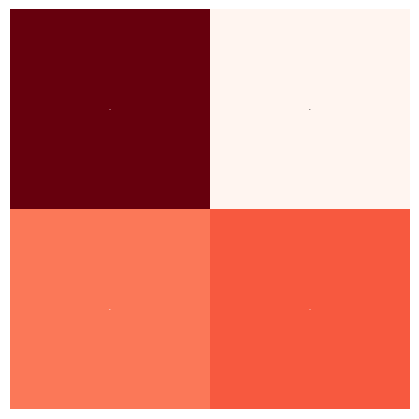

--------- Train neuralop-medium_frac25 ------------
              precision    recall  f1-score   support

   anueploid       0.94      0.44      0.60       323
     euploid       0.63      0.97      0.76       313

    accuracy                           0.70       636
   macro avg       0.78      0.71      0.68       636
weighted avg       0.79      0.70      0.68       636



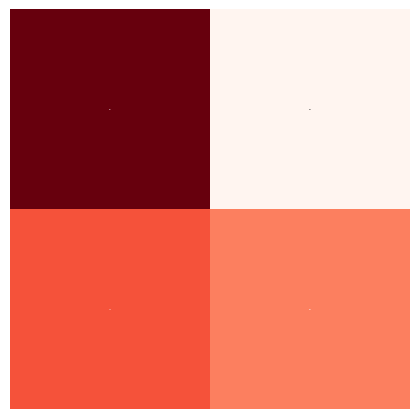

--------- Test neuralop-medium_frac25 ------------
              precision    recall  f1-score   support

   anueploid       0.92      0.48      0.64        97
     euploid       0.66      0.96      0.79       103

    accuracy                           0.73       200
   macro avg       0.79      0.72      0.71       200
weighted avg       0.79      0.73      0.71       200



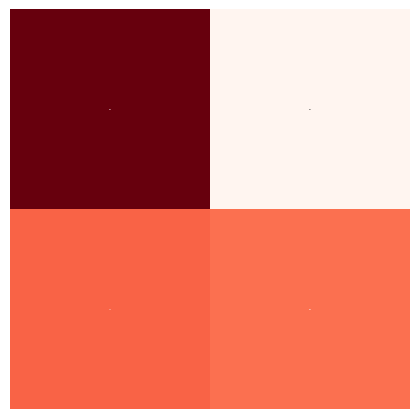

--------- Train neuralop-medium_frac5 ------------
              precision    recall  f1-score   support

   anueploid       0.97      0.80      0.88       220
     euploid       0.81      0.97      0.88       192

    accuracy                           0.88       412
   macro avg       0.89      0.88      0.88       412
weighted avg       0.89      0.88      0.88       412



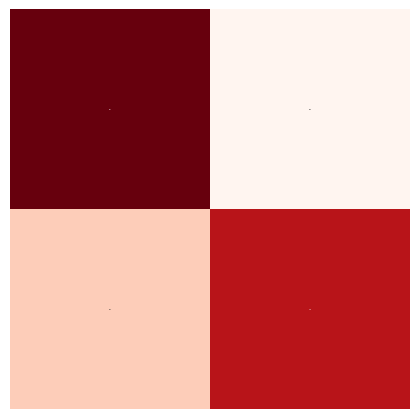

--------- Test neuralop-medium_frac5 ------------
              precision    recall  f1-score   support

   anueploid       0.91      0.70      0.79        56
     euploid       0.80      0.95      0.87        74

    accuracy                           0.84       130
   macro avg       0.86      0.82      0.83       130
weighted avg       0.85      0.84      0.83       130



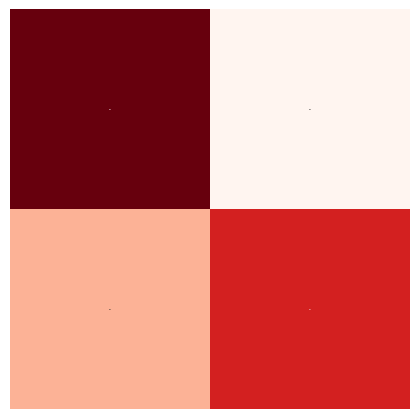

--------- Train neuralop-medium_frac50 ------------
              precision    recall  f1-score   support

   anueploid       0.99      0.39      0.56       348
     euploid       0.60      0.99      0.75       320

    accuracy                           0.68       668
   macro avg       0.79      0.69      0.65       668
weighted avg       0.80      0.68      0.65       668



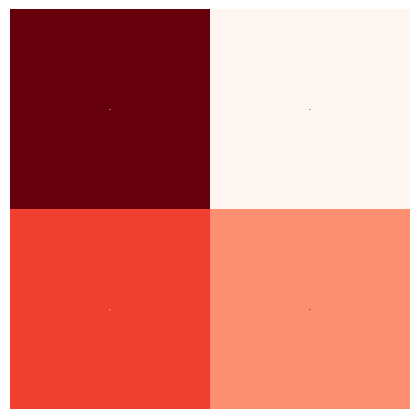

--------- Test neuralop-medium_frac50 ------------
              precision    recall  f1-score   support

   anueploid       0.98      0.47      0.64       102
     euploid       0.66      0.99      0.80       108

    accuracy                           0.74       210
   macro avg       0.82      0.73      0.72       210
weighted avg       0.82      0.74      0.72       210



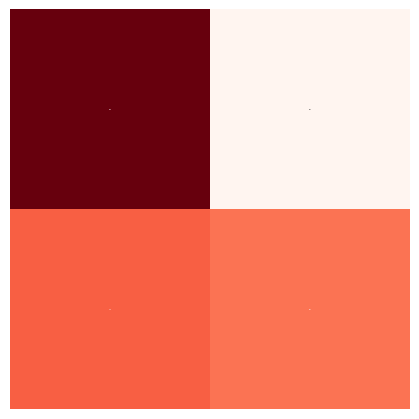

--------- Train neuralop-medium_frac75 ------------
              precision    recall  f1-score   support

   anueploid       0.83      0.36      0.50       343
     euploid       0.58      0.92      0.71       326

    accuracy                           0.63       669
   macro avg       0.70      0.64      0.60       669
weighted avg       0.70      0.63      0.60       669



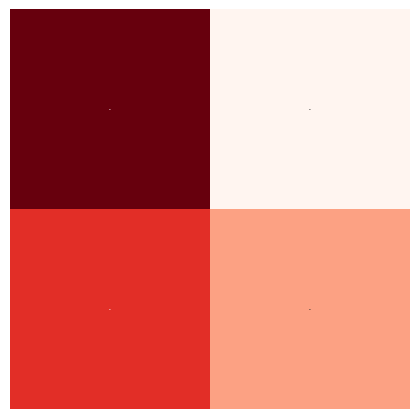

--------- Test neuralop-medium_frac75 ------------
              precision    recall  f1-score   support

   anueploid       0.76      0.35      0.48        98
     euploid       0.61      0.90      0.73       112

    accuracy                           0.64       210
   macro avg       0.68      0.62      0.60       210
weighted avg       0.68      0.64      0.61       210



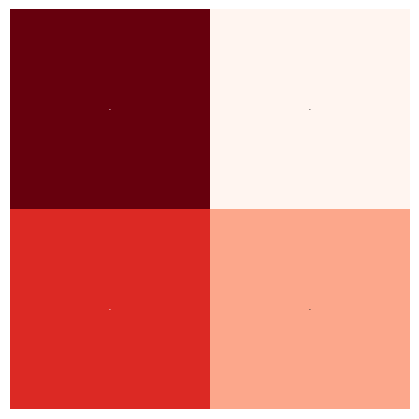

In [37]:
for model_name, dataset in best_pca_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        test_loader = loader.get_dataloader("test")

        pca_info = pcas[model_name][dataset_name]
        pca_list = pca_info["pca_list"]
        mean = pca_info["mean"]
        std = pca_info["std"]

        def get_pca_input(embeddings):
            normalized = (embeddings - mean) / std
            pca_transformed = []
            for t, pca in enumerate(pca_list):
                X_t = normalized[:, t].cpu().numpy()
                X_pca = pca.transform(X_t)
                pca_transformed.append(torch.tensor(X_pca, dtype=torch.float32))
            return torch.stack(pca_transformed, dim=1).to(embeddings.device)

        for split_name, split_loader in zip(["train", "test"], [train_loader, test_loader]):
            y_true_labels = []
            y_pred_labels = []
            sample_id_list = []

            model.eval()
            with torch.no_grad():
                for embeddings, sample_id in split_loader:
                    y_batch = transform_sample_id(sample_id)
                    pca_input = get_pca_input(embeddings)
                    y_pred = model(pca_input)
                    y_true_labels.extend(y_batch.numpy())
                    y_pred_labels.extend(y_pred.flatten().numpy())
                    sample_id_list.extend(sample_id)

            y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
            y_test_original = [inverse_mapping[label] for label in y_true_labels]
            y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

            print(f"--------- {split_name.capitalize()} {model_name} ------------")
            print(classification_report(y_test_original, y_pred_original, zero_division=0))

            save_path = f"figures/plots/cm_{model_name}_{split_name}.png"
            plot_classification_results(y_true_labels, y_pred_labels,
                                        f"{model_name} | {dataset_name}",
                                        ["euploid", "aneuploid"], save_path)

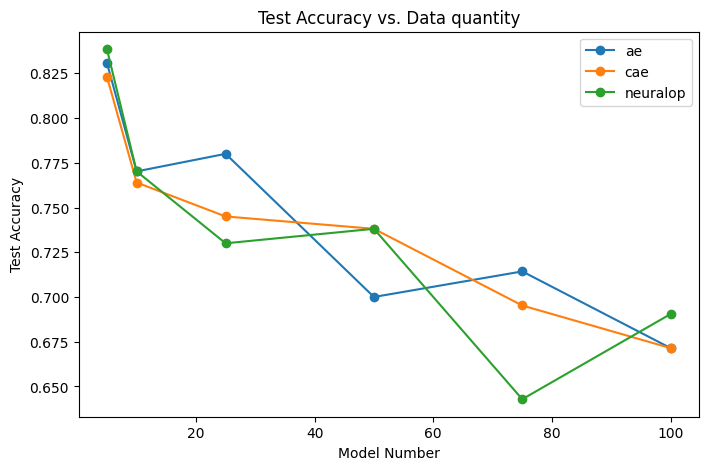

In [47]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

results = []

for model_name, dataset in best_pca_models.items():
    frac = model_name.split("_")[1]
    frac = frac.replace("frac", "")
    frac = int(frac)
    
    base_model = model_name.split("-")[0]
    
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader("test")
        pca_info = pcas[model_name][dataset_name]
        pca_list = pca_info["pca_list"]
        mean = pca_info["mean"]
        std = pca_info["std"]

        def get_pca_input(embeddings):
            normalized = (embeddings - mean) / std
            pca_transformed = []
            for t, pca in enumerate(pca_list):
                X_t = normalized[:, t].cpu().numpy()
                X_pca = pca.transform(X_t)
                pca_transformed.append(torch.tensor(X_pca, dtype=torch.float32))
            return torch.stack(pca_transformed, dim=1).to(embeddings.device)

        # Collect predictions for test split
        y_true_labels = []
        y_pred_labels = []
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                y_batch = transform_sample_id(sample_id)
                pca_input = get_pca_input(embeddings)
                y_pred = model(pca_input)
                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())

        y_pred_binary = [int(label > 0.5) for label in y_pred_labels]
        acc = accuracy_score(y_true_labels, y_pred_binary)

        results.append({
            "model": base_model,
            "data_frac": frac,
            "dataset": dataset_name,
            "accuracy": acc
        })

df_results = pd.DataFrame(results)
df_results.sort_values("data_frac", inplace=True)

plt.figure(figsize=(8, 5))
for model, group in df_results.groupby("model"):
    plt.plot(group["data_frac"], group["accuracy"], marker="o", label=model)

plt.xlabel("Model Number")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs. Data quantity")
plt.legend()
plt.show()

In [ ]:
all_pca_results_data = {
    "study_name": f"{study_name}_pca",
    "model_dataset_results": []
}

for model_name, dataset in best_pca_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        pca_info = pcas[model_name][dataset_name]
        mean = pca_info["mean"]
        std = pca_info["std"]
        pca_list = pca_info["pca_list"]

        def apply_pca_batch(batch):
            normalized = (batch - mean) / std
            transformed = []
            for t in range(normalized.shape[1]):
                flattened = normalized[:, t].numpy().reshape(normalized.shape[0], -1)
                transformed.append(pca_list[t].transform(flattened))
            return torch.tensor(np.stack(transformed, axis=1), dtype=torch.float32)

        model.eval()
        correct = []
        incorrect = []

        for split_loader in [train_loader, val_loader, test_loader]:
            y_true_labels = []
            y_pred_labels = []
            sample_id_list = []

            with torch.no_grad():
                for embeddings, sample_id in split_loader:
                    x_batch = apply_pca_batch(embeddings)
                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(x_batch)

                    y_true_labels.extend(y_batch.numpy())
                    y_pred_labels.extend(y_pred.flatten().numpy())
                    sample_id_list.extend(sample_id)

            y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
            y_true_original = [inverse_mapping[label] for label in y_true_labels]
            y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

            correct.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt == yp])
            incorrect.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt != yp])

        current_model_dataset_results = {
            "model_name": model_name,
            "dataset_name": dataset_name,
            "total_correct": len(correct),
            "total_incorrect": len(incorrect),
            "correct_predictions": correct,
            "incorrect_predictions": incorrect
        }

        all_pca_results_data["model_dataset_results"].append(current_model_dataset_results)

# Save to file
# json_filename = f"results_downstream/{study_name}_classification_results_pca.json"
# with open(json_filename, 'w') as f:
#     json.dump(all_pca_results_data, f, indent=4)

In [ ]:
def permutation_importance_pca_aggregated(
    model, test_loader, transform_sample_id, pca_transform_fn, baseline_score, num_iterations=10
):
    model.eval()

    sample_batch = next(iter(test_loader))[0]
    sample_pca = pca_transform_fn(sample_batch)
    num_features = sample_pca.shape[-1]

    importance_scores = np.zeros(num_features)

    for _ in range(num_iterations):
        iteration_importance = []

        for feature_idx in range(num_features):
            y_pred_permuted = []
            y_true = []

            with torch.no_grad():
                for embeddings, sample_id in test_loader:
                    pca_embeddings = pca_transform_fn(embeddings).clone()
                    pca_embeddings[:, :, feature_idx] = pca_embeddings[:, torch.randperm(pca_embeddings.size(1)), feature_idx]

                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(pca_embeddings)

                    y_true.extend(y_batch.numpy())
                    y_pred_permuted.extend((y_pred.flatten().numpy() > 0.5).astype(int))

            permuted_score = accuracy_score(y_true, y_pred_permuted)
            importance = baseline_score - permuted_score
            iteration_importance.append(importance)

        importance_scores += np.array(iteration_importance)

    importance_scores /= num_iterations
    feature_importance = sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)
    return feature_importance

def visualize_pca_feature_tuning(
    pca_info,
    model,
    pca_sample,
    feature_idx,
    time_idx=8,
    variation_range=(-3, 3),
    steps=7,
):
    assert steps % 2 == 1, "Steps must be odd to have a midpoint"

    original_pca = pca_sample[time_idx]
    pca_list = pca_info["pca_list"]
    pca = pca_list[time_idx]
    mean = pca_info["mean"][0, time_idx].numpy()
    std = pca_info["std"][0, time_idx].numpy()

    feature_values = np.linspace(*variation_range, steps)
    mid_idx = steps // 2

    # Get the original image
    original_inv = pca.inverse_transform(original_pca)
    original_denorm = original_inv * std + mean
    original_img = model.decode_image(torch.tensor(original_denorm).float().unsqueeze(0)).squeeze().detach().cpu().numpy()

    def plot_side(values, name_suffix):
        fig, axes = plt.subplots(1, len(values), figsize=(2 * len(values), 3))
        if len(values) == 1:                       # <─ add this block
            axes = [axes]
            
        for i, val in enumerate(values):
            perturbed = original_pca.copy()
            perturbed[feature_idx] += val
            inverse = pca.inverse_transform(perturbed)
            denorm = inverse * std + mean
            decoded = model.decode_image(torch.tensor(denorm).float().unsqueeze(0)).squeeze().detach().cpu().numpy()

            diff_image = decoded - original_img
            cmap = 'gray'
            vmax = np.max(np.abs(diff_image))
            vmin = -vmax

            axes[i].imshow(diff_image, cmap=cmap, vmin=vmin, vmax=vmax)
            # axes[i].set_title(f"{val:+.2f}", fontsize=10)
            axes[i].axis('off')

        fig.tight_layout(pad=0.3)
        # fig.savefig(f"figures/pca_feature_tuning_{model.name}_t{time_idx}_pc{feature_idx}_{name_suffix}.png", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

    # Plot negative side
    plot_side(feature_values[:mid_idx], "negative")

    # Plot positive side
    plot_side(feature_values[mid_idx+1:], "positive")

In [ ]:
top_pca_features = defaultdict(lambda: defaultdict(list))

for model_name, dataset in best_pca_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader("test")

        pca_info = pcas[model_name][dataset_name]
        pca_list = pca_info["pca_list"]
        mean = pca_info["mean"]
        std = pca_info["std"]

        def get_pca_input(embeddings):
            normalized = (embeddings - mean) / std
            pca_transformed = []
            for t, pca in enumerate(pca_list):
                X_t = normalized[:, t].cpu().numpy()
                X_pca = pca.transform(X_t)
                pca_transformed.append(torch.tensor(X_pca, dtype=torch.float32))
            return torch.stack(pca_transformed, dim=1).to(embeddings.device)

        y_true_labels, y_pred_labels = [], []
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                pca_input = get_pca_input(embeddings)
                y_batch = transform_sample_id(sample_id)
                y_pred = model(pca_input)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend((y_pred.flatten().numpy() > 0.5).astype(int))

        baseline_acc = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\nBaseline Accuracy for {model_name} | {dataset_name}: {baseline_acc:.4f}")

        feature_importances = permutation_importance_pca_aggregated(
            model, test_loader, transform_sample_id, get_pca_input, baseline_acc, num_iterations=100
        )

        top_pca_features[model_name][dataset_name] = feature_importances
        print("Average FI in PCA space (over 25 iterations):")
        for idx, imp in feature_importances:
            print(f"  PC {idx}: importance = {imp:.4f}")

In [ ]:
target_array = 1
target_raft = 127
target_prefix = f"array{target_array}_{target_raft}"

autoencoders = load_models(results_path, num_timepoints=seq_len, best_models_flag=True)
autoencoders = dict(sorted(autoencoders.items()))

random_samples_pca = defaultdict(lambda: defaultdict(list))
for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader('test')
        dataset = test_loader.dataset

        index = None
        for i in range(len(dataset)):
            _, sample_id = dataset[i]
            if target_prefix in sample_id:
                index = i
                break

        if index is None:
            print(f"No sample found for {target_prefix} in {model_name} - {dataset_name}")
            continue

        latent_seq, sample_id = dataset[index]
        print(f"Selected sample index: {index} | Sample ID: {sample_id}")
        
        mean = pcas[model_name][dataset_name]["mean"]
        std = pcas[model_name][dataset_name]["std"]
        normalized = (latent_seq - mean) / std 

        pca_list = pcas[model_name][dataset_name]["pca_list"]

        pca_data = []
        for t, pca in enumerate(pca_list):
            flattened = normalized[0, t].numpy().reshape(1, -1)
            transformed = pca.transform(flattened)
            pca_data.append(transformed.squeeze(0))

        pca_transformed = np.stack(pca_data)

        random_samples_pca[model_name][dataset_name] = pca_transformed

In [ ]:
avg_pca_trajectories = defaultdict(lambda: defaultdict(list))

marker_styles = ['o', 's', '^', 'D', 'v', 'X']
gray_color = 'black'
faint_line_color = 'gray'
faint_line_style = '--'

for model_name, dataset in autoencoders.items():
    print(model_name)
    for dataset_name, encoder_model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader("test")
        dataset = test_loader.dataset

        pca_info = pcas[model_name][dataset_name]
        mean = pca_info["mean"]
        std = pca_info["std"]
        pca_list = pca_info["pca_list"]

        num_timepoints = len(pca_list)
        num_pcs = pca_list[0].n_components_
        sum_pca = np.zeros((num_timepoints, num_pcs))
        count = 0

        for raw_seq, _ in dataset:
            raw_seq = raw_seq.unsqueeze(0)
            normalized = (raw_seq - mean) / std
            pca_data = []

            for t, pca in enumerate(pca_list):
                transformed = pca.transform(normalized[0, t].numpy().reshape(1, -1))
                pca_data.append(transformed.squeeze(0))

            sum_pca += np.stack(pca_data, axis=0)
            count += 1

        avg_pca = sum_pca / count
        avg_pca_trajectories[model_name][dataset_name] = avg_pca

        top_pcs = top_pca_features[model_name][dataset_name]
        fig, ax = plt.subplots(figsize=(12, 6))
        lines = []
        labels = []

        for i in range(6):
            pc_idx = top_pcs[i][0]
            marker = marker_styles[i % len(marker_styles)]

            ax.plot(range(num_timepoints), avg_pca[:, pc_idx],
                    color=faint_line_color, linestyle=faint_line_style, linewidth=1.0)

            line = ax.plot(range(num_timepoints), avg_pca[:, pc_idx],
                           label=f"PC {pc_idx+1}", color=gray_color,
                           linestyle='None', marker=marker, markerfacecolor='gray', markersize=15, linewidth=2.0)[0]
            lines.append(line)
            labels.append(f"PC {pc_idx+1}")

        ax.tick_params(axis='x', which='both', length=0, labelbottom=False)
        ax.tick_params(axis='y', which='both', length=0, labelleft=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(False)
        plt.tight_layout()
        plt.savefig(f"figures/gastruloid/pca_trajectory_{model_name}_{dataset_name}.png", dpi=300)
        plt.show()

        legend_fig, legend_ax = plt.subplots(figsize=(4, 2))
        legend = legend_ax.legend(handles=lines, labels=labels, loc='center', frameon=False)
        legend_ax.axis('off')
        plt.tight_layout()
        plt.savefig(f"figures/gastruloid/legend_{model_name}_{dataset_name}.png", dpi=300, bbox_inches='tight')
        plt.show()

In [ ]:
# for model_name, dataset in best_pca_models.items():
#     for dataset_name, model in dataset.items():
#         loader = loaders[model_name][dataset_name]
#         test_loader = loader.get_dataloader("test")
#         pca_info = pcas[model_name][dataset_name]
#         pca_list = pca_info["pca_list"]
#         mean = pca_info["mean"]
#         std = pca_info["std"]
#         variance_explained = pca_info["variance_explained"]

#         timepoint_list = []
#         all_pca_embeddings = []

#         with torch.no_grad():
#             for embeddings, sample_id in test_loader:
#                 for i in range(embeddings.size(0)):
#                     y_batch = transform_sample_id(sample_id)
#                     latent = embeddings[i].cpu().numpy()
#                     latent = (latent - mean[t]) / std[t]
#                     pca = pca_list[t]
#                     pca_embedding = pca.transform(latent.reshape(1, -1)).squeeze()
#                     timepoint_list.append(t)
#                     all_pca_embeddings.append(pca_embedding)

#         # Organize by timepoint
#         tp_to_embeddings = defaultdict(list)
#         for t, emb in zip(timepoint_list, all_pca_embeddings):
#             tp_to_embeddings[t].append(emb)

#         sorted_timepoints = sorted(tp_to_embeddings.keys())
#         num_pcs = all_pca_embeddings[0].shape[0]

#         dim_trajectories = [[] for _ in range(num_pcs)]
#         for t in sorted_timepoints:
#             arr = np.stack(tp_to_embeddings[t])
#             mean_vals = arr.mean(axis=0)
#             for d in range(num_pcs):
#                 dim_trajectories[d].append(mean_vals[d])

#         # Plot
#         fig, ax = plt.subplots(figsize=(12, 6))
#         for d in range(num_pcs):
#             var = variance_explained[d] if d < len(variance_explained) else 0.0
#             ax.plot(sorted_timepoints, dim_trajectories[d], label=f'PC {d+1} ({var:.1%})', linewidth=4)

#         ax.tick_params(axis='x', labelsize=24)
#         ax.tick_params(axis='y', labelsize=24)
#         ax.grid(True)
#         ax.legend(fontsize=14, loc='upper left')
#         plt.title(f'{model_name} | {dataset_name} - PCA Trajectories', fontsize=18)
#         plt.tight_layout()
#         plt.show()

In [ ]:
time_idx = 8

for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        pca_info = pcas[model_name][dataset_name]
        pca_sample = random_samples_pca[model_name][dataset_name]
        pca_vector = pca_sample[time_idx]
        pca_model = pca_info["pca_list"][time_idx]
        num_pcs = pca_model.components_.shape[0]

        print(f"Model: {model_name} | Dataset: {dataset_name} | Timepoint: {time_idx}")
        encoder_model.eval()
        with torch.no_grad():
            for pc_idx in range(num_pcs):
                print(f"  Visualizing PC {pc_idx}")
                visualize_pca_feature_tuning(
                    pca_info,
                    encoder_model,
                    pca_sample,
                    feature_idx=pc_idx,
                    time_idx=time_idx,
                    variation_range=(-2, 2),
                    steps=3
                )

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt

# --- Step 1: Create a Differentiable PCA Transformation Module ---
# This module replicates the scikit-learn PCA transform using PyTorch operations.

class TemporalPCATransformer(nn.Module):
    def __init__(self, pca_list, mean, std):
        super().__init__()
        self.pca_list = pca_list
        self.mean = nn.Parameter(mean, requires_grad=False)
        self.std = nn.Parameter(std, requires_grad=False)
        
        # Extract components and means from sklearn PCA objects and store as tensors
        self.pca_components = nn.ParameterList()
        self.pca_means = nn.ParameterList()
        for pca in self.pca_list:
            components = torch.tensor(pca.components_, dtype=torch.float32)
            mean_ = torch.tensor(pca.mean_, dtype=torch.float32)
            self.pca_components.append(nn.Parameter(components, requires_grad=False))
            self.pca_means.append(nn.Parameter(mean_, requires_grad=False))

    def forward(self, embeddings):
        # Assumes embeddings shape is [batch, time, features]
        normalized = (embeddings - self.mean) / (self.std + 1e-8)
        
        pca_transformed = []
        for t in range(normalized.shape[1]):
            # Get the data for the current timestep
            X_t = normalized[:, t]
            
            # Replicate pca.transform(X_t) using PyTorch
            # (X - pca_mean) @ pca_components.T
            X_centered = X_t - self.pca_means[t]
            X_pca = torch.matmul(X_centered, self.pca_components[t].T)
            pca_transformed.append(X_pca)
            
        # Stack the results back into a temporal sequence
        pca_input = torch.stack(pca_transformed, dim=1)
        return pca_input

# --- Step 2: Main Logic to Generate and Plot Grad-CAM ---

# Choose a few samples to visualize
N_SAMPLES_TO_VISUALIZE = 3

# Assuming 'GradCAM' class is defined in a previous cell
# Assuming 'transform_sample_id' function is defined

for model_name, dataset in best_pca_models.items():
    for dataset_name, downstream_model in dataset.items():
        print(f"--- Generating Grad-CAM for: {model_name} | {dataset_name} ---")
        
        # --- A. Load all necessary components ---
        base_model = temporal_models[model_name][dataset_name][0] # Assuming the first model is the base
        base_encoder = base_model.encoder # Adjust if your base model structure is different
        
        pca_info = pcas[model_name][dataset_name]
        
        test_loader = loaders[model_name][dataset_name].get_dataloader("test")
        
        # --- B. Build the full, end-to-end differentiable model ---
        pca_transformer = TemporalPCATransformer(pca_info['pca_list'], pca_info['mean'], pca_info['std'])
        
        full_pipeline = nn.Sequential(
            base_encoder,
            pca_transformer,
            downstream_model
        ).to(next(base_model.parameters()).device)
        
        # --- C. Select a target layer for Grad-CAM from the BASE model ---
        # This must be a spatial layer, e.g., the last Conv2d or FNOBlocks
        # IMPORTANT: Adjust this line to match your base_encoder's architecture
        target_layer = base_encoder.features[-1] 
        
        # --- D. Run Grad-CAM on a few test samples ---
        for i, (embeddings, sample_id) in enumerate(test_loader):
            if i >= N_SAMPLES_TO_VISUALIZE:
                break
            
            # NOTE: We need the original input to the base_encoder, not the embeddings.
            # This part requires you to modify your dataloader to also yield the original data.
            # For demonstration, let's assume `original_data` is available.
            # original_data, embeddings, sample_id = ...
            
            # This is a placeholder. You MUST get the original spatial data that produced the embedding.
            original_data = torch.randn(1, 1, 64, 64).to(embeddings.device) # EXAMPLE SHAPE
            original_data.requires_grad_(True)
            
            # --- Generate the saliency map ---
            grad_cam_generator = GradCAM(model=full_pipeline, target_layer=target_layer)
            
            logits = full_pipeline(original_data).squeeze()
            predicted_class = (logits > 0.5).long().item()
            target_for_grad_cam = logits # Using the logit itself as the target
            
            saliency_map = grad_cam_generator(original_data, target=target_for_grad_cam)
            
            # --- Plot the result ---
            original_image_np = original_data.squeeze().detach().cpu().numpy()
            saliency_np = saliency_map.detach().cpu().numpy()
            
            plt.figure(figsize=(10, 5))
            
            # Original Image
            plt.subplot(1, 2, 1)
            plt.imshow(original_image_np, cmap='gray')
            plt.title("Original Input")
            plt.axis('off')

            # Overlay
            plt.subplot(1, 2, 2)
            plt.imshow(original_image_np, cmap='gray')
            plt.imshow(saliency_np, cmap='jet', alpha=0.5) # Overlay
            plt.title(f"Grad-CAM (Predicted: {predicted_class})")
            plt.axis('off')
            
            plt.suptitle(f"{model_name} / {dataset_name}")
            plt.show()